**Load Tools**

In [1]:
!pip uninstall tensorflow keras protobuf -y
!pip cache purge
!pip install tensorflow keras protobuf==3.20.3

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Successfully uninstalled keras-3.8.0
Found existing installation: protobuf 6.33.0
Uninstalling protobuf-6.33.0:
  Successfully uninstalled protobuf-6.33.0
Files removed: 0
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.4 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstallin

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve

from keras.models import Sequential,load_model
from keras.layers import Dense,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping,ModelCheckpoint

2025-11-15 15:29:19.042106: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763220559.067017      19 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763220559.074199      19 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763220559.093668      19 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763220559.093714      19 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763220559.093717      19 computation_placer.cc:177] computation placer alr

**Loading Data**

In [3]:
train_data = pd.read_csv("/kaggle/input/banknote/train.csv")
test_data = pd.read_csv("/kaggle/input/banknote/test.csv")
train_data.head()

,VWTI,SWTI,CWTI,EI,Class
0,2.2634,-4.4862,3.6558,-0.612510,0
1,3.2718,1.7837,2.1161,0.613340,0
2,-3.9411,-12.8792,13.0597,-3.312500,1
3,0.5195,-3.2633,3.0895,-0.984900,0
4,2.5698,-4.4076,5.9856,0.078002,0


In [4]:
print(f"Training Data Contain {train_data.shape[0]} Rows & {train_data.shape[1]} Columns")
print(f"Testing Data Contain {test_data.shape[0]} Rows & {test_data.shape[1]} Columns")

Training Data Contain 1096 Rows & 5 Columns
Testing Data Contain 275 Rows & 4 Columns


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VWTI    1096 non-null   float64
 1   SWTI    1096 non-null   float64
 2   CWTI    1096 non-null   float64
 3   EI      1096 non-null   float64
 4   Class   1096 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 42.9 KB


In [6]:
train_data.describe()

,VWTI,SWTI,CWTI,EI,Class
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,0.448500,1.780643,1.493533,-1.157454,0.445255
std,2.852623,5.922621,4.375655,2.084983,0.497221
min,-7.036400,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.790850,-2.125200,-1.574975,-2.246975,0.000000
50%,0.540430,2.205850,0.671900,-0.569190,0.000000
75%,2.835350,6.793925,3.574450,0.399980,1.000000
max,6.563300,12.730200,17.927400,2.449500,1.000000


In [7]:
train_data.isnull().sum()

VWTI     0
SWTI     0
CWTI     0
EI       0
Class    0
dtype: int64

In [8]:
train_data[train_data.duplicated()]

,VWTI,SWTI,CWTI,EI,Class
209,0.5195,-3.2633,3.0895,-0.9849,0
239,-1.3000,10.2678,-2.9530,-5.8638,0
289,-2.6479,10.1374,-1.3310,-5.4707,0
572,0.3292,-4.4552,4.5718,-0.9888,0
604,-1.8584,7.8860,-1.6643,-1.8384,0
644,-0.2780,8.1881,-3.1338,-2.5276,0
658,-1.3000,10.2678,-2.9530,-5.8638,0
661,-2.6479,10.1374,-1.3310,-5.4707,0
665,0.3292,-4.4552,4.5718,-0.9888,0
747,0.5195,-3.2633,3.0895,-0.9849,0


**EDA**

In [9]:
train_data.Class.value_counts().to_frame()

,count
Class,
0,608
1,488


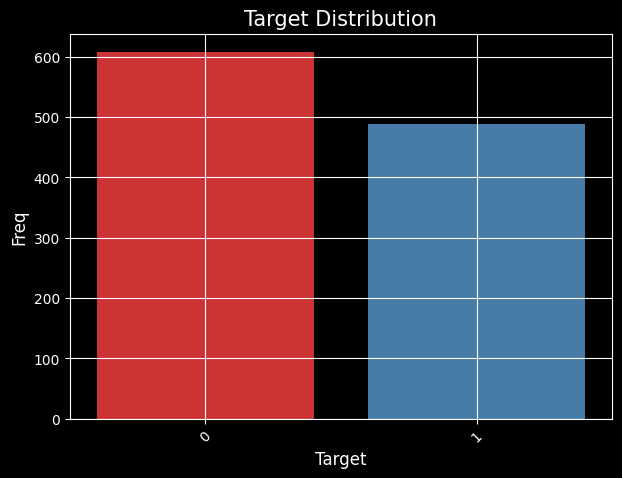

In [10]:
plt.style.use("dark_background")
plt.figure(figsize=(7,5))
sns.countplot(x="Class",data=train_data,palette="Set1")
plt.title("Target Distribution",fontsize=15)
plt.xticks(rotation=45)
plt.xlabel("Target",fontsize=12)
plt.ylabel("Freq",fontsize=12)
plt.grid(True)
plt.show()

**Preprocessing**

In [11]:
X_train,X_test,y_train,y_test = train_test_split(train_data.drop("Class",axis=1),train_data["Class"],test_size=.2
                                                 ,shuffle=True,random_state=44,stratify=train_data["Class"])
print(f"X Train Size: {X_train.shape} & X Test Size: {X_test.shape}")
print(f"Y Train Size: {y_train.shape} & Y Test Size: {y_test.shape}")

X Train Size: (876, 4) & X Test Size: (220, 4)
Y Train Size: (876,) & Y Test Size: (220,)


**ANN**

In [12]:
model = Sequential()
model.add(Dense(64,activation="relu",input_shape=(X_train.shape[1],)))
model.add(Dropout(.2))
model.add(BatchNormalization())
model.add(Dense(32,activation="relu"))
model.add(Dropout(.2))
model.add(BatchNormalization())
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763220570.981937      19 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
checkpoint_cb =ModelCheckpoint("Notes_model.keras", save_best_only=True)
# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping,checkpoint_cb]  
)

Epoch 1/15


I0000 00:00:1763220575.025283      77 service.cc:152] XLA service 0x7f5258010490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763220575.025313      77 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763220575.429007      77 cuda_dnn.cc:529] Loaded cuDNN version 90300


21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5605 - loss: 0.7145 

I0000 00:00:1763220577.343457      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.6529 - loss: 0.6400 - val_accuracy: 0.7898 - val_loss: 0.4810
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8700 - loss: 0.3686 - val_accuracy: 0.9148 - val_loss: 0.3393
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9514 - loss: 0.2262 - val_accuracy: 0.9602 - val_loss: 0.2349
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9614 - loss: 0.1596 - val_accuracy: 0.9830 - val_loss: 0.1538
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9814 - loss: 0.1124 - val_accuracy: 1.0000 - val_loss: 0.1006
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9800 - loss: 0.0911 - val_accuracy: 1.0000 - val_loss: 0.0663
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9843 - loss: 0.0706 - val_accuracy: 1.0000 - val_loss: 0.0469
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9843 - loss: 0.0576 - val_accuracy: 1.0000 - val_loss: 0.0333
E

In [14]:
hist = pd.DataFrame(history.history)
hist

,accuracy,loss,val_accuracy,val_loss
0,0.652857,0.640007,0.789773,0.481032
1,0.870000,0.368643,0.914773,0.339345
2,0.951429,0.226201,0.960227,0.234901
3,0.961429,0.159637,0.982955,0.153806
4,0.981429,0.112387,1.000000,0.100597
5,0.980000,0.091143,1.000000,0.066261
6,0.984286,0.070637,1.000000,0.046933
7,0.984286,0.057576,1.000000,0.033271
8,0.982857,0.051754,1.000000,0.024649
9,0.992857,0.033637,1.000000,0.018612


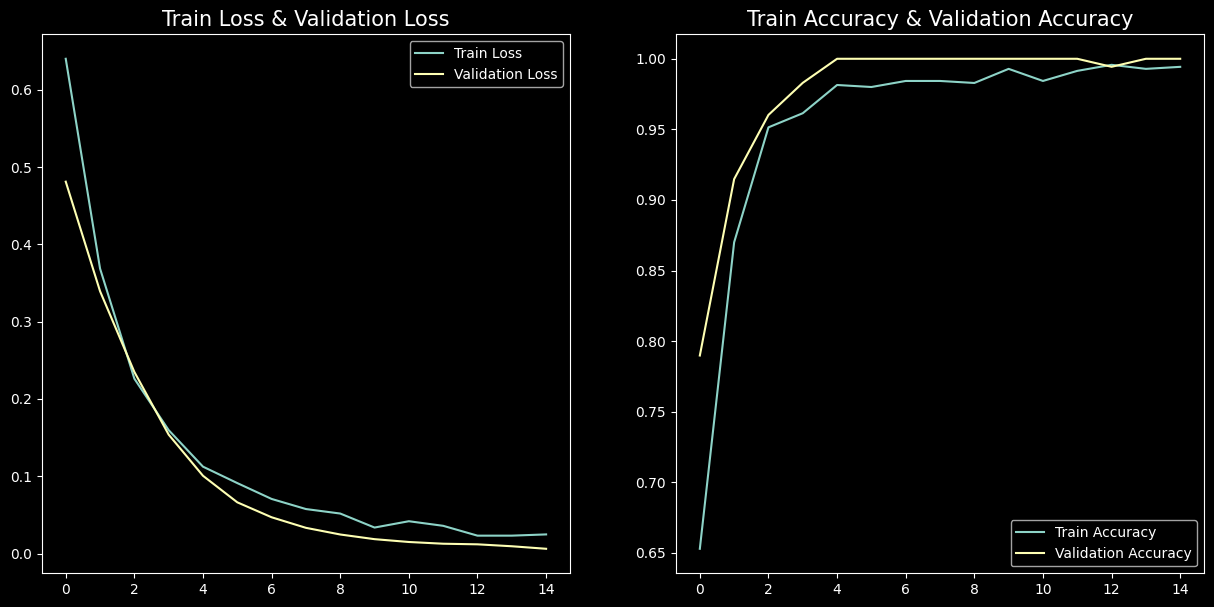

In [15]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.plot(hist['loss'],label='Train Loss')
plt.plot(hist['val_loss'],label='Validation Loss')
plt.title('Train Loss & Validation Loss',fontsize=15)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist['accuracy'],label='Train Accuracy')
plt.plot(hist['val_accuracy'],label='Validation Accuracy')
plt.title('Train Accuracy & Validation Accuracy',fontsize=15)
plt.legend()
plt.show()

**Evaluation**

In [16]:
model = load_model("Notes_model.keras")

In [17]:
loss,acc = model.evaluate(X_test,y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 0.0084
Test Loss: 0.0084, Test Accuracy: 1.0000


**Metrics**

In [18]:
y_pred_pro = model.predict(X_test)
y_pred = (y_pred_pro >= .5).astype(int)
y_pred[:5]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


array([[0],
       [1],
       [0],
       [0],
       [1]])

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


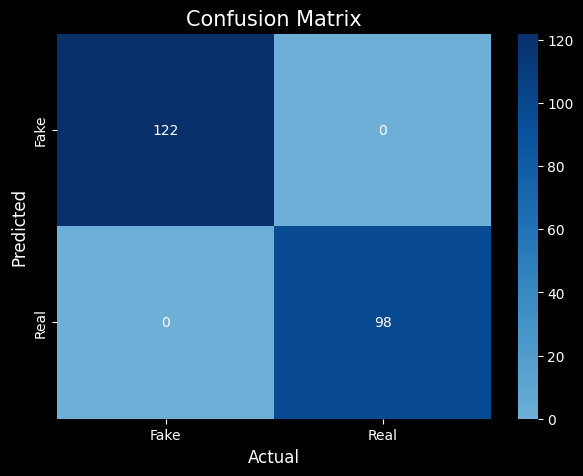

array([[122,   0],
       [  0,  98]])

In [19]:
CM = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(CM,fmt='g',center=True,annot=True,xticklabels=["Fake","Real"],yticklabels=["Fake","Real"],cmap='Blues')
plt.ylabel("Predicted",fontsize=12)
plt.xlabel("Actual",fontsize=12)
plt.title("Confusion Matrix",fontsize=15)
plt.show()
CM

In [20]:
print("Classification Report:\n",classification_report(y_test,y_pred,target_names=["Fake","Real"]))

Classification Report:
               precision    recall  f1-score   support

        Fake       1.00      1.00      1.00       122
        Real       1.00      1.00      1.00        98

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



ROC AUC Score: 1.000



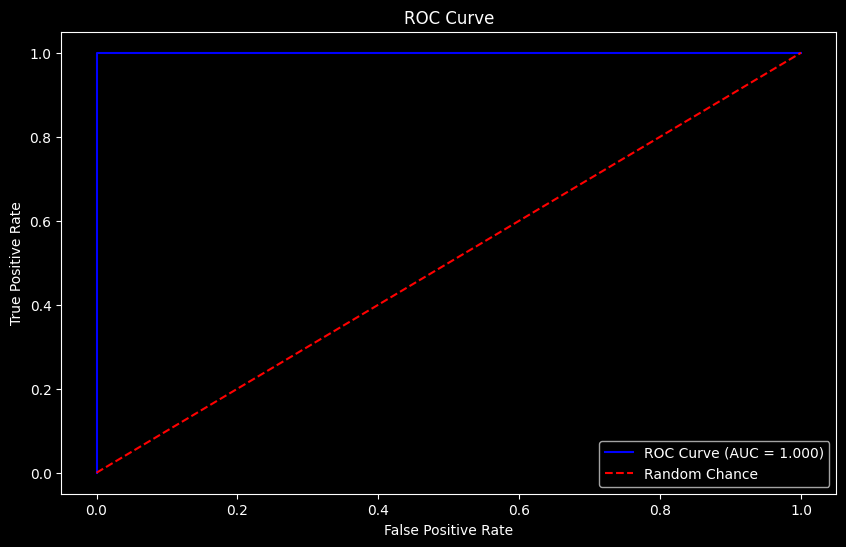

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_pred_pro)
roc_auc = roc_auc_score(y_test, y_pred_pro)
print(f'ROC AUC Score: {roc_auc:.3f}\n')
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve')
plt.legend(loc='lower right')
plt.show()

**Test Prediction**

In [22]:
pred = (model.predict(test_data) >= .5).astype(int)
test_data["Class"] = pred
test_data["Class"].replace(0,"Fake",inplace=True)
test_data["Class"].replace(1,"Real",inplace=True)
test_data

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


/tmp/ipykernel_19/4276047914.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data["Class"].replace(0,"Fake",inplace=True)


,VWTI,SWTI,CWTI,EI,Class
0,-0.40804,0.542140,-0.52725,0.658600,Real
1,-3.71810,-8.508900,12.36300,-0.955180,Real
2,5.50400,10.367100,-4.41300,-4.021100,Fake
3,1.68490,8.748900,-1.26410,-1.385800,Fake
4,4.74320,2.108600,0.13680,1.654300,Fake
...,...,...,...,...,...
270,-1.00500,0.084831,-0.24620,0.456880,Real
271,2.21230,-5.839500,7.76870,-0.853020,Fake
272,4.38460,-4.879400,3.36620,-0.029324,Fake
273,3.88400,10.027700,-3.92980,-4.081900,Fake
